# AutoML (sustituto de AutoSklearn) con **PyCaret** — Dataset *Iris* (Scikit-Learn)

**Objetivo docente (para alumnado novato):** ver el pipeline completo de Machine Learning de forma práctica:

1. Cargar datos (dataset Iris).
2. Definir el problema (clasificación multiclase).
3. Preparar datos automáticamente (AutoML).
4. Comparar modelos y elegir el mejor.
5. Evaluar el modelo.
6. Interpretar (mínimo) qué variables influyen y cómo se comporta el modelo.
7. Guardar el modelo para usarlo después.

> Este notebook está pensado para ejecutarse en **Google Colab**.  
> Si algo no funciona, el 90% de las veces es porque no se ha **reiniciado el entorno** tras instalar librerías.


## 0) Preparación del entorno (Colab)

PyCaret es una librería “todo en uno” para AutoML. En Colab normalmente se instala sin problemas, pero **hay que reiniciar el runtime** tras instalar.

**Qué vas a decir en clase:**  
“Vamos a instalar una herramienta de AutoML que automatiza gran parte del trabajo repetitivo: preparación, comparación de modelos y evaluación”.


In [ ]:
# --- Instalación (Google Colab) ---
# Nota: si ya está instalado, no pasa nada por repetir.
# Si falla, prueba a reiniciar el entorno y ejecutar de nuevo.

!pip -q install --upgrade pip



# IMPORTANTE (DOCENTE):
# Tras instalar PyCaret, reinicia el runtime:
# Entorno de ejecución -> Reiniciar entorno de ejecución


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.2 MB/s eta 0:00:00


## **MUY IMPORTANTE, TRAS LA INSTALACIÓN ANTERIOR HAY QUE REINICIAR SESIÓN EN ENTORNO DE EJECICIÓN ANTES DE INSTALAR LAS LIBRERÍA**

In [ ]:
!pip -q install "numpy==1.26.4" "scipy==1.11.4" "pandas==2.1.4" "scikit-learn==1.4.2"


In [ ]:
!pip -q install "pycaret==3.3.2"

In [ ]:
import numpy as np, pandas as pd, scipy
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scipy", scipy.__version__)

from pycaret.classification import *
print("PyCaret import OK")

numpy 1.26.4
pandas 2.1.4
scipy 1.11.4
PyCaret import OK


## 1) Cargar el dataset (Iris)

Vamos a usar el dataset **Iris** (muy típico para empezar) porque:

- es pequeño y rápido,
- tiene 4 variables numéricas,
- la etiqueta (target) tiene 3 clases de flor.

**Problema:** clasificación multiclase (predecir la especie de la flor).


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

# Convertimos a DataFrame para trabajar más cómodo
df = iris.frame.copy()  # incluye features + target

# Renombramos la columna objetivo para que sea más clara en clase
df = df.rename(columns={"target": "species"})

# Mapeo de 0/1/2 a nombres de clase (opcional pero didáctico)
target_names = {i: name for i, name in enumerate(iris.target_names)}
df["species_name"] = df["species"].map(target_names)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Qué estamos viendo

- Las columnas numéricas son las **features** (variables de entrada).
- `species` es el **target** (lo que queremos predecir).
- `species_name` es una versión “humana” del target (para entenderlo en clase).

> Para PyCaret usaremos como target `species` (numérico).  
> `species_name` lo dejaremos para visualizar.


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
sepal width (cm),150.0,NaN,NaN,NaN,3.057333,0.435866,2.0,2.8,3.0,3.3,4.4
petal length (cm),150.0,NaN,NaN,NaN,3.758,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,NaN,NaN,NaN,1.199333,0.762238,0.1,0.3,1.3,1.8,2.5
species,150.0,NaN,NaN,NaN,1.0,0.819232,0.0,0.0,1.0,2.0,2.0
species_name,150,3,setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2) AutoML con PyCaret: `setup()`

`setup()` es el paso clave: PyCaret detecta el tipo de variables y prepara el pipeline.

**Qué vas a decir en clase:**  
“En un proyecto real aquí haríamos limpieza, tratamiento de nulos, escalado, etc. PyCaret lo automatiza y nos deja el entorno listo para comparar modelos”.

Notas:
- PyCaret crea internamente un “hold-out” (un test) para evaluar.
- También usa validación cruzada para comparar modelos.


In [ ]:
from pycaret.classification import setup

# Importante:
# - target = columna a predecir
# - session_id fija la aleatoriedad para que a todos les salga parecido
# - silent y verbose: para que no bombardee la salida en clase
# - use_gpu=False: para evitar errores con GPUs en Colab

clf_setup = setup(
    data=df.drop(columns=["species_name"]),  # quitamos la columna de texto
    target="species",
    session_id=42,
    train_size=0.8,
    fold=5,
    normalize=True,            # escalado automático (muy útil para algunos modelos)
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95,
    verbose=False
)


### Lo importante del `setup()`

- **train_size=0.8** → 80% entrenamiento, 20% test (hold-out).
- **fold=5** → validación cruzada de 5 particiones para comparar modelos.
- **normalize=True** → escalado automático (para explicar que algunos modelos lo necesitan).

> En esta fase PyCaret prepara un pipeline: es decir, una cadena de transformaciones + modelo.


## 3) Comparar modelos automáticamente: `compare_models()`

Aquí hacemos AutoML “de verdad”: PyCaret entrena varios modelos y los ordena por rendimiento.

**Qué vas a decir en clase:**  
“En lugar de elegir ‘a dedo’ el algoritmo, probamos muchos y nos quedamos con el mejor según una métrica”.


In [ ]:
from pycaret.classification import compare_models

best_model = compare_models(sort="Accuracy")
best_model


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.9750,0.0000,0.9750,0.9778,0.9749,0.9625,0.9640,0.0400
lr,Logistic Regression,0.9583,0.0000,0.9583,0.9644,0.9580,0.9375,0.9408,1.9820
lda,Linear Discriminant Analysis,0.9583,0.0000,0.9583,0.9659,0.9578,0.9375,0.9417,0.0400
nb,Naive Bayes,0.9500,0.9948,0.9500,0.9552,0.9497,0.9250,0.9278,0.0400
rf,Random Forest Classifier,0.9500,0.9878,0.9500,0.9585,0.9494,0.9250,0.9297,0.2240
lightgbm,Light Gradient Boosting Machine,0.9500,0.9875,0.9500,0.9561,0.9496,0.9250,0.9283,0.2480
knn,K Neighbors Classifier,0.9417,0.9909,0.9417,0.9469,0.9419,0.9125,0.9148,0.0660
dt,Decision Tree Classifier,0.9417,0.9562,0.9417,0.9511,0.9410,0.9125,0.9177,0.0460
svm,SVM - Linear Kernel,0.9417,0.0000,0.9417,0.9493,0.9411,0.9125,0.9167,0.0500
gbc,Gradient Boosting Classifier,0.9417,0.0000,0.9417,0.9475,0.9412,0.9125,0.9158,0.3060


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                              store_covariance=False, tol=0.0001)

## 4) Crear el modelo ganador y evaluar

Aunque `compare_models()` ya devuelve el mejor, lo normal es:

- **crear** el modelo final,
- **evaluarlo** con el conjunto de test (hold-out),
- y mirar métricas y matriz de confusión.


In [ ]:
from pycaret.classification import create_model, evaluate_model, predict_model, pull

# Creamos el modelo (PyCaret lo re-entrena con el pipeline configurado)
final_model = create_model(best_model)

# Tabla de métricas de la última operación
results_table = pull()
results_table


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9583,0.0000,0.9583,0.9630,0.9582,0.9375,0.9400
1,0.9583,0.0000,0.9583,0.9630,0.9582,0.9375,0.9400
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9583,0.0000,0.9583,0.9630,0.9582,0.9375,0.9400
4,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Mean,0.9750,0.0000,0.9750,0.9778,0.9749,0.9625,0.9640
Std,0.0204,0.0000,0.0204,0.0181,0.0205,0.0306,0.0294


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9583,0.0,0.9583,0.9630,0.9582,0.9375,0.9400
1,0.9583,0.0,0.9583,0.9630,0.9582,0.9375,0.9400
2,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9583,0.0,0.9583,0.9630,0.9582,0.9375,0.9400
4,1.0000,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
Mean,0.9750,0.0,0.9750,0.9778,0.9749,0.9625,0.9640
Std,0.0204,0.0,0.0204,0.0181,0.0205,0.0306,0.0294


### Evaluación visual (para clase)

`evaluate_model()` abre un panel interactivo con plots (ROC, Confusion Matrix, etc.).

> En Colab puede tardar unos segundos en cargar.


In [ ]:
# Panel interactivo de evaluación
evaluate_model(final_model)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

## 5) Predicciones sobre el hold-out (test)

`predict_model()` evalúa el modelo sobre el conjunto hold-out interno de PyCaret y nos devuelve:

- predicción (`prediction_label`)
- probabilidad de la clase predicha (`prediction_score`)


In [ ]:
pred_holdout = predict_model(final_model)
pred_holdout.head()


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Quadratic Discriminant Analysis,0.9333,0.9967,0.9333,0.9333,0.9333,0.9000,0.9000


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,prediction_label,prediction_score
38,4.4,3.0,1.3,0.2,0,0,1.0000
127,6.1,3.0,4.9,1.8,2,2,0.8834
57,4.9,2.4,3.3,1.0,1,1,0.9996
93,5.0,2.3,3.3,1.0,1,1,0.9994
42,4.4,3.2,1.3,0.2,0,0,1.0000


## 6) Interpretación básica del modelo

En dos sesiones no conviene entrar en teoría dura, pero sí es útil enseñar:

- qué variables parecen más importantes (según el modelo),
- y un par de gráficos.

> Ojo: no todos los modelos soportan todos los plots, pero PyCaret lo gestiona bastante bien.


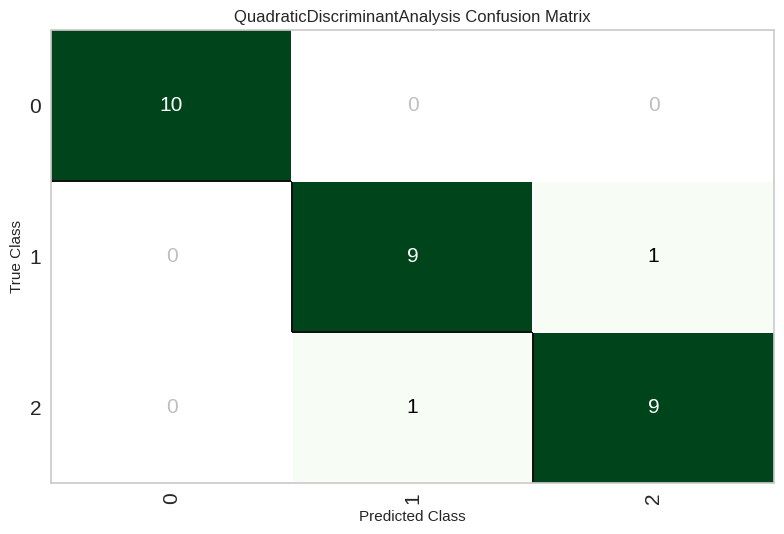

In [ ]:
from pycaret.classification import plot_model

# Matriz de confusión (hold-out)
plot_model(final_model, plot="confusion_matrix")


## 7) Guardar el modelo

Esto es clave para aterrizar “proyecto real”:

- entreno el modelo una vez,
- lo guardo,
- y luego lo cargo para predecir nuevos datos.


In [ ]:
from pycaret.classification import save_model, load_model

save_model(final_model, "pycaret_iris_automl_model")

loaded = load_model("pycaret_iris_automl_model")

loaded


Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded


Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['sepal length (cm)',
                                             'sepal width (cm)',
                                             'petal length (cm)',
                                             'petal width (cm)'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),
                ('categorical_imputer',
                 Tr...
                 TransformerWrapper(exclude=None, include=None,
                                    transformer=StandardScaler(copy=True,
                                                               with_mean=True,
                                                               with_std=True))),
                ('clean_column_names',
                 TransformerWrapper(exclude=None, include=None,
                                    transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
                ('trained_model',
                 QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                                               store_covariance=False,
                                               tol=0.0001))],
         verbose=False)

## 8) Predicción sobre nuevos datos (ejemplo)

Creamos 2 filas “nuevas” (features) y pedimos al modelo una predicción.


In [ ]:
import numpy as np

# Dos ejemplos nuevos (4 features del Iris):
# sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
new_samples = pd.DataFrame(
    [
        [5.1, 3.5, 1.4, 0.2],
        [6.4, 2.8, 5.6, 2.2],
    ],
    columns=iris.feature_names
)

new_pred = predict_model(loaded, data=new_samples)
new_pred


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),prediction_label,prediction_score
0,5.1,3.5,1.4,0.2,0,1.0
1,6.4,2.8,5.6,2.2,2,1.0


from matplotlib import pyplot as plt
new_pred['sepal length (cm)'].plot(kind='hist', bins=20, title='sepal length (cm)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
new_pred['sepal width (cm)'].plot(kind='hist', bins=20, title='sepal width (cm)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
new_pred['petal length (cm)'].plot(kind='hist', bins=20, title='petal length (cm)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
new_pred['petal width (cm)'].plot(kind='hist', bins=20, title='petal width (cm)')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['petal length (cm)']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'petal length (cm)'}, axis=1)
              .sort_values('petal length (cm)', ascending=True))
  xs = counted['petal length (cm)']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = new_pred.sort_values('petal length (cm)', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('petal length (cm)')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
new_pred['sepal length (cm)'].plot(kind='line', figsize=(8, 4), title='sepal length (cm)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
new_pred['sepal width (cm)'].plot(kind='line', figsize=(8, 4), title='sepal width (cm)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
new_pred['petal length (cm)'].plot(kind='line', figsize=(8, 4), title='petal length (cm)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
new_pred['petal width (cm)'].plot(kind='line', figsize=(8, 4), title='petal width (cm)')
plt.gca().spines[['top', 'right']].set_visible(False)

# Conclusión (para cerrar la sesión)

Hoy hemos visto el pipeline completo sin entrar en matemáticas:

- Cargamos un dataset.
- Definimos el objetivo (clasificación).
- Usamos AutoML para **comparar modelos** automáticamente.
- Seleccionamos el mejor, lo evaluamos y miramos métricas.
- Hicimos una interpretación básica.
- Guardamos el modelo y lo usamos para predecir nuevos datos.

**Lo siguiente (Sesión 2):** explicaremos el problema de la “caja negra” y haremos interpretabilidad con **SHAP** (para entender *por qué* el modelo decide lo que decide).
